##**[5주차]실습**
- 아래의 실습1), 실습2). 실습3)의 코드를 완성하시오.


###**실습1) 과잉 적합과 과소 적합(Overfitting, Underfitting)**
- **[실습목표]** 예제를 통해 실제로 과잉적합 되는 학습을 수행하고, 가중치 규제(weigt regularization), 드롭아웃(Dropout)방법을 사용하여 이를 완화해본다.



####**실습 1-1)**
- 영화 리뷰를 분류하는 IMDB 데이터세트를 통해, 리뷰 데이터를 기반으로 긍정적, 부정적 리뷰를 구분하는 모델을 작성한다.

In [ ]:
print("2353881, 최대영")

In [1]:
from google.colab import auth

auth.authenticate_user()
!gcloud config get-value account

tigers7101@gmail.com


In [2]:
import numpy as numpy
import tensorflow as tf
import matplotlib.pyplot as plt

# 데이터 다운로드
(train_data, train_labels), (test_data, test_labels) = \
    tf.keras.datasets.imdb.load_data(num_words=1000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# 원-핫 인코딩으로 변환하는 함수
def one_hot_sequences(sequences, dimension=1000):
    results = numpy.zeros((len(sequences), dimension))
    for i, word_index in enumerate(sequences):
      results[i, word_index] = 1
    return results

In [5]:
# 학습 loss 그래프를 출력하는 함수
def print_plot(history):
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.title('Loss Plot')
  plt.ylabel('loss')
  plt.xlabel('epochs')
  plt.legend(['train error', 'val error'], loc='upper left')
  plt.show()

In [6]:
train_data = one_hot_sequences(train_data)
test_data = one_hot_sequences(test_data)

In [8]:
# 신경망 모델 구축
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(1000,)))
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])



In [9]:
# 신경망 훈련, 검증 데이터 전달
history = model.fit(train_data,
                    train_labels,
                    epochs=20,
                    batch_size=512,
                    validation_data=(test_data, test_labels),
                    verbose=2)

Epoch 1/20
49/49 - 3s - 63ms/step - accuracy: 0.7058 - loss: 0.5839 - val_accuracy: 0.8154 - val_loss: 0.4382
Epoch 2/20
49/49 - 0s - 8ms/step - accuracy: 0.8442 - loss: 0.3713 - val_accuracy: 0.8558 - val_loss: 0.3447
Epoch 3/20
49/49 - 0s - 8ms/step - accuracy: 0.8666 - loss: 0.3207 - val_accuracy: 0.8604 - val_loss: 0.3314
Epoch 4/20
49/49 - 0s - 8ms/step - accuracy: 0.8724 - loss: 0.3082 - val_accuracy: 0.8620 - val_loss: 0.3302
Epoch 5/20
49/49 - 0s - 8ms/step - accuracy: 0.8752 - loss: 0.3021 - val_accuracy: 0.8596 - val_loss: 0.3286
Epoch 6/20
49/49 - 0s - 8ms/step - accuracy: 0.8781 - loss: 0.2991 - val_accuracy: 0.8591 - val_loss: 0.3301
Epoch 7/20
49/49 - 0s - 8ms/step - accuracy: 0.8766 - loss: 0.2979 - val_accuracy: 0.8590 - val_loss: 0.3293
Epoch 8/20
49/49 - 0s - 8ms/step - accuracy: 0.8799 - loss: 0.2932 - val_accuracy: 0.8590 - val_loss: 0.3300
Epoch 9/20
49/49 - 1s - 12ms/step - accuracy: 0.8789 - loss: 0.2916 - val_accuracy: 0.8588 - val_loss: 0.3302
Epoch 10/20
49/49

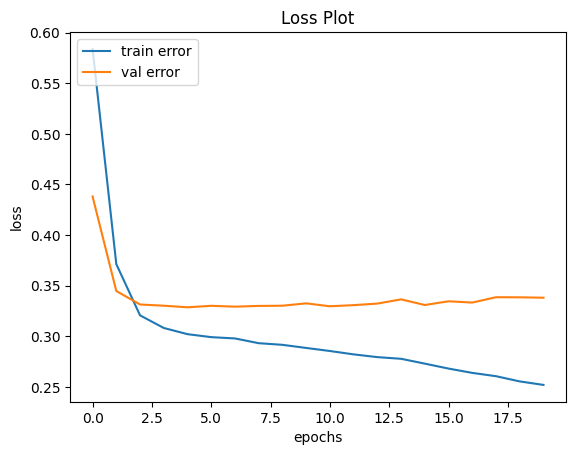

In [10]:
# 훈련 데이터의 손실값과 검증 데이터의 손실값을 그래프에 출력
print_plot(history)

####**실습1-2)**
- 실습 1-1)의 결과를 통해, 학습이 진행됨에 따라 과잉적합되는 학습의 경향을 확인할 수 있다.
- 가중치 규제 방법을 사용하여, 과잉적합을 완화해본다.

In [13]:
# 신경망 모델 구축
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(16, kernel_regularizer=tf.keras.regularizers.l2(0.001), activation='relu', input_shape=(1000,)))
model.add(tf.keras.layers.Dense(16, kernel_regularizer=tf.keras.regularizers.l2(0.001), activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 신경망 훈련, 검증 데이터 전달
history = model.fit(train_data,
                    train_labels,
                    epochs=20,
                    batch_size=512,
                    validation_data=(test_data, test_labels),
                    verbose=2)

Epoch 1/20
49/49 - 2s - 39ms/step - accuracy: 0.7227 - loss: 0.6117 - val_accuracy: 0.8179 - val_loss: 0.4786
Epoch 2/20
49/49 - 0s - 8ms/step - accuracy: 0.8438 - loss: 0.4163 - val_accuracy: 0.8552 - val_loss: 0.3883
Epoch 3/20
49/49 - 0s - 8ms/step - accuracy: 0.8652 - loss: 0.3649 - val_accuracy: 0.8594 - val_loss: 0.3717
Epoch 4/20
49/49 - 0s - 9ms/step - accuracy: 0.8715 - loss: 0.3512 - val_accuracy: 0.8606 - val_loss: 0.3668
Epoch 5/20
49/49 - 1s - 13ms/step - accuracy: 0.8730 - loss: 0.3459 - val_accuracy: 0.8603 - val_loss: 0.3689
Epoch 6/20
49/49 - 1s - 11ms/step - accuracy: 0.8740 - loss: 0.3400 - val_accuracy: 0.8591 - val_loss: 0.3642
Epoch 7/20
49/49 - 1s - 14ms/step - accuracy: 0.8758 - loss: 0.3366 - val_accuracy: 0.8607 - val_loss: 0.3624
Epoch 8/20
49/49 - 1s - 14ms/step - accuracy: 0.8746 - loss: 0.3362 - val_accuracy: 0.8600 - val_loss: 0.3624
Epoch 9/20
49/49 - 1s - 12ms/step - accuracy: 0.8773 - loss: 0.3311 - val_accuracy: 0.8590 - val_loss: 0.3636
Epoch 10/20
4

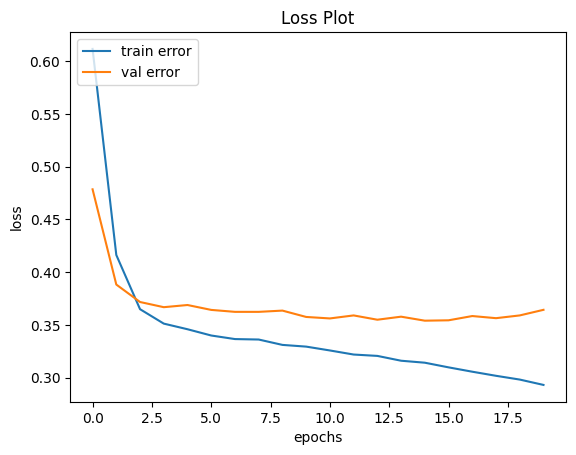

In [14]:
# 훈련 데이터의 손실값과 검증 데이터의 손실값을 그래프에 출력
print_plot(history)

####**실습1-3)**
- 드롭아웃을 수행하여, 과대적합을 완화해본다.

In [18]:
# 신경망 모델 구축
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(16, activation='relu', input_shape=(1000,)))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])



# 신경망 훈련, 검증 데이터 전달
history = model.fit(train_data,
                    train_labels,
                    epochs=20,
                    batch_size=512,
                    validation_data=(test_data, test_labels),
                    verbose=2)

Epoch 1/20
49/49 - 2s - 41ms/step - accuracy: 0.5405 - loss: 0.6947 - val_accuracy: 0.6545 - val_loss: 0.6735
Epoch 2/20
49/49 - 0s - 8ms/step - accuracy: 0.6436 - loss: 0.6480 - val_accuracy: 0.7900 - val_loss: 0.5857
Epoch 3/20
49/49 - 0s - 9ms/step - accuracy: 0.7399 - loss: 0.5681 - val_accuracy: 0.8342 - val_loss: 0.4817
Epoch 4/20
49/49 - 0s - 8ms/step - accuracy: 0.7841 - loss: 0.5062 - val_accuracy: 0.8452 - val_loss: 0.4282
Epoch 5/20
49/49 - 0s - 9ms/step - accuracy: 0.8069 - loss: 0.4684 - val_accuracy: 0.8540 - val_loss: 0.3888
Epoch 6/20
49/49 - 0s - 9ms/step - accuracy: 0.8251 - loss: 0.4371 - val_accuracy: 0.8567 - val_loss: 0.3647
Epoch 7/20
49/49 - 0s - 8ms/step - accuracy: 0.8345 - loss: 0.4189 - val_accuracy: 0.8568 - val_loss: 0.3567
Epoch 8/20
49/49 - 0s - 8ms/step - accuracy: 0.8393 - loss: 0.4053 - val_accuracy: 0.8598 - val_loss: 0.3443
Epoch 9/20
49/49 - 0s - 8ms/step - accuracy: 0.8424 - loss: 0.3930 - val_accuracy: 0.8578 - val_loss: 0.3380
Epoch 10/20
49/49 

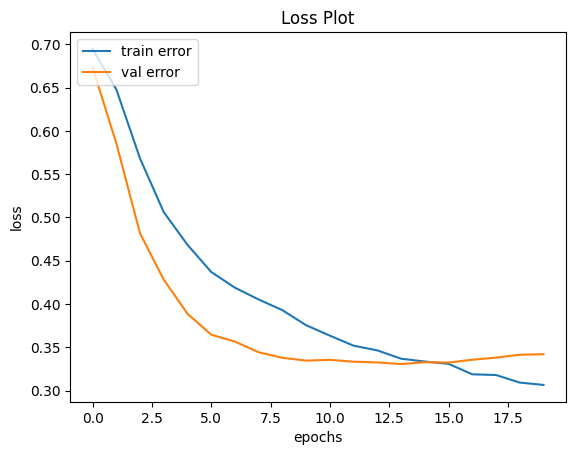

In [19]:
# 훈련 데이터의 손실값과 검증 데이터의 손실값을 그래프에 출력
print_plot(history)

###**실습2) MNIST 필기체 숫자 인식**
- **[실습목표]** tensorflow를 활용하여, MNIST dataset의 classification을 수행하는 MLP모델을 구출해본다.


In [20]:
import matplotlib.pyplot as plt
import tensorflow as tf

mnist = tf.keras.datasets.mnist

(x_train, y_train),(x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [26]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
model.add(tf.keras.layers.Dense(512, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)
loss, acc = model.evaluate(x_test, y_test)
print(f"loss: {loss}, acc: {acc}")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9331 - loss: 0.2217
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9705 - loss: 0.0959
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.9784 - loss: 0.0678
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9828 - loss: 0.0531
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9856 - loss: 0.0439
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9818 - loss: 0.0612
loss: 0.06118212267756462, acc: 0.9818000197410583


###**실습3) 패션 아이템 분류**
- **[실습목표]** fasion mnist dataset을 classification 하는 MLP 모델을 구축해본다.
- **Fashion MNIST**
  - 28x28 픽셀의 회색조(grayscale) 이미지 70,000개로 구성(traning set 60,000개, test set 10,000)
  - 10개의 클래스로 구성되며, 각 클래스는 티셔츠/탑, 바지, 스웨터, 신발 등의 패션 아이템을 나타냄.


In [27]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, layers, models

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


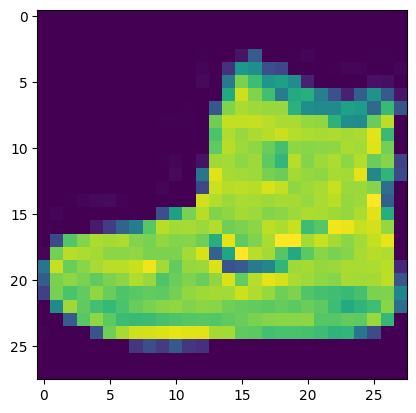

In [28]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

plt.imshow(train_images[0])

In [29]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [31]:
model = models.Sequential()
model.add(layers.Flatten(input_shape=(28, 28)))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8242 - loss: 0.5028
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8637 - loss: 0.3785
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8756 - loss: 0.3373
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8838 - loss: 0.3143
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8918 - loss: 0.2943


In [32]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('정확도:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8743 - loss: 0.3499
정확도: 0.8743000030517578
